In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 5.9 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/40.2 MB 5.9 MB/s eta 0:00:07
   --- ------------------------------------ 3.4/40.2 MB 5.9 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/40.2 MB 5.7 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/40.2 MB 5.6 MB/s eta 0:00:07
   ------ --------------------------------- 6.6/40.2 MB 5.3 MB/s eta 0:00:07
   ------- -------------------------------- 7.9/40.2 MB 5.4 MB/s eta 0:00:06
   -------- ------------------------------- 8.9/40.2 MB 5.5 MB/s eta 0:00:06
   ---------- ----------------------------- 10.2/40.2 MB 5.5 MB/s eta 0:00:06
   ----------- ---------------------------- 11.5/40.2 MB 5.6 MB/s eta 0:00:06
   ------------ --------------------------- 12.8/40.2 MB 5.6 MB/s eta 0:00:05
   -------------- ------------------------- 14.2/40.2 MB 5.6 MB/s eta 0:00:05
  


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import copy
import time
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from pathlib import Path
import gc

In [3]:
# ============================================================
# 1. AYARLAR
# ============================================================
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 100
SEED       = 42
LR         = 0.005
VAL_SPLIT  = 0.15

TRAIN_DIR = r"C:\Users\User\Desktop\DermNet\train"
TEST_DIR  = r"C:\Users\User\Desktop\DermNet\test"

MODEL_SAVE_PATH  = "best_resnet50_model.pth"
PROBS_SAVE_PATH  = "probabilities_resnet50.npy"
LABELS_SAVE_PATH = "test_labels_resnet50.npy"
CM_SAVE_PATH     = "confusion_matrix_resnet50.jpg"

ROI_CACHE_DIR = r"C:\Users\User\Desktop\DermNet\roi_cache"

TARGET_CLASSES = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Scabies",
    "Tinea"
]

print(f"IMG_SIZE: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning Rate: {LR}")
print(f"Hedef sınıf sayısı: {len(TARGET_CLASSES)}")

IMG_SIZE: 224
Batch size: 16
Learning Rate: 0.005
Hedef sınıf sayısı: 5


In [4]:
# ============================================================
# 2. SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_seed(SEED)

In [5]:
# ============================================================
# 3. DEVICE (CUDA / CPU)
# ============================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Kullanılan cihaz: CUDA - {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info(0)
    print(f"VRAM: {total / 1024**3:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ CUDA bulunamadı! CPU kullanılacak.")

Kullanılan cihaz: CUDA - NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB


In [6]:
# ============================================================
# 4. PATH KONTROL
# Hedef sınıf klasörlerinin varlığı kontrol ediliyor.
# ============================================================
print("Train yolu var mı:", os.path.exists(TRAIN_DIR))
print("Test yolu var mı :", os.path.exists(TEST_DIR))

if not os.path.exists(TRAIN_DIR) or not os.path.exists(TEST_DIR):
    print("\n⚠️ Dosya yolları bulunamadı!")
    print("TRAIN_DIR ve TEST_DIR değişkenlerini düzenle.")
    print(f"Şu an aranan TRAIN: {TRAIN_DIR}")
    print(f"Şu an aranan TEST : {TEST_DIR}")
else:
    print("\nHedef sınıf kontrolü:")
    for cls in TARGET_CLASSES:
        train_path = os.path.join(TRAIN_DIR, cls)
        test_path = os.path.join(TEST_DIR, cls)
        train_ok = os.path.exists(train_path)
        test_ok = os.path.exists(test_path)
        status = "✅" if (train_ok and test_ok) else "❌"
        print(f"  {status} {cls}")
        if not train_ok:
            print(f"      ⚠️ Train klasörü bulunamadı: {train_path}")
        if not test_ok:
            print(f"      ⚠️ Test klasörü bulunamadı: {test_path}")

Train yolu var mı: True
Test yolu var mı : True

Hedef sınıf kontrolü:
  ✅ Acne
  ✅ Eczema
  ✅ Psoriasis
  ✅ Scabies
  ✅ Tinea


In [7]:
# ============================================================
# 5. ROI (Region of Interest) FONKSİYONU
# ============================================================
def extract_roi(image_path, target_size=224):
    """
    Görüntüden lezyon bölgesini (ROI) otomatik tespit eder ve kırpar.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (11, 11), 0)

    _, thresh = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        img_area = img.shape[0] * img.shape[1]

        if area < img_area * 0.01 or area > img_area * 0.95:
            roi = img_rgb
        else:
            x, y, w, h = cv2.boundingRect(largest)

            pad_x = int(w * 0.15)
            pad_y = int(h * 0.15)

            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(img.shape[1], x + w + pad_x)
            y2 = min(img.shape[0], y + h + pad_y)

            roi = img_rgb[y1:y2, x1:x2]
    else:
        roi = img_rgb

    roi = cv2.resize(roi, (target_size, target_size))
    return roi

In [8]:
# ============================================================
# 5.5 ROI ÖNBELLEK FONKSİYONU
# ============================================================
def get_cached_roi(image_path, target_size=224):
    cache_dir = Path(ROI_CACHE_DIR)
    cache_dir.mkdir(parents=True, exist_ok=True)

    key = hashlib.md5(image_path.encode()).hexdigest()
    cache_path = cache_dir / f"{key}.npy"

    if cache_path.exists():
        return np.load(cache_path)

    roi = extract_roi(image_path, target_size)
    if roi is not None:
        np.save(cache_path, roi)
    return roi

print(f"ROI önbellek klasörü: {ROI_CACHE_DIR}")

ROI önbellek klasörü: C:\Users\User\Desktop\DermNet\roi_cache


In [9]:
# ============================================================
# 6. ROI DATASET SINIFI
# ============================================================
class ROIDataset(Dataset):
    def __init__(self, root_dir, transform=None, target_size=224,
                 use_cache=True, target_classes=None):
        self.root_dir = root_dir
        self.transform = transform
        self.target_size = target_size
        self.use_cache = use_cache
        self.roi_fail_count = 0
        self.total_loaded = 0

        if target_classes is not None:
            self.classes = sorted([
                d for d in target_classes
                if os.path.isdir(os.path.join(root_dir, d))
            ])
        else:
            self.classes = sorted([
                d for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ])

        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                fpath = os.path.join(cls_dir, fname)
                if os.path.isfile(fpath) and fname.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp", ".webp")
                ):
                    self.samples.append((fpath, self.class_to_idx[cls]))

        print(f"{root_dir} -> {len(self.samples)} görüntü yüklendi")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            if self.use_cache:
                roi = get_cached_roi(img_path, self.target_size)
            else:
                roi = extract_roi(img_path, self.target_size)

            if roi is None:
                self.roi_fail_count += 1
                img = Image.open(img_path).convert("RGB").resize(
                    (self.target_size, self.target_size)
                )
            else:
                img = Image.fromarray(roi)

            self.total_loaded += 1

            if self.transform:
                img = self.transform(img)

            return img, label

        except Exception as e:
            print(f"Hata: {img_path} -> {e}")
            fallback = Image.new("RGB", (self.target_size, self.target_size), (0, 0, 0))
            if self.transform:
                fallback = self.transform(fallback)
            return fallback, label

In [10]:
# ============================================================
# 6.5 TRANSFORM WRAPPER
# ============================================================
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        pil_img, label = self.subset[idx]
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label

In [11]:
# ============================================================
# 7. TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.15,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# ============================================================
# 8. DATASET YÜKLEME
# [v5] WeightedRandomSampler eklendi
# [v5] ROI kalite kontrolü kapalı — cache zaten oluşturulmuş
# ============================================================
NUM_WORKERS = 0

print("Train verileri ROI ile yükleniyor (sadece hedef sınıflar)...")
full_train_dataset = ROIDataset(
    TRAIN_DIR,
    transform=None,
    target_size=IMG_SIZE,
    target_classes=TARGET_CLASSES
)

class_names = full_train_dataset.classes
NUM_CLASSES = len(class_names)

print(f"Sınıf sayısı: {NUM_CLASSES}")
print(f"Sınıflar: {class_names}")

print("\nSınıf dağılımı:")
for cls in class_names:
    count = sum(1 for _, label in full_train_dataset.samples
                if full_train_dataset.classes[label] == cls)
    print(f"  {cls}: {count} görüntü")

train_size = int((1 - VAL_SPLIT) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, eval_transform)

test_dataset = ROIDataset(
    TEST_DIR,
    transform=eval_transform,
    target_size=IMG_SIZE,
    target_classes=TARGET_CLASSES
)

subset_labels = [train_subset.dataset.samples[i][1] for i in train_subset.indices]
subset_class_counts = np.bincount(subset_labels, minlength=NUM_CLASSES)
sample_weights = [1.0 / subset_class_counts[label] for label in subset_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train verileri ROI ile yükleniyor (sadece hedef sınıflar)...
C:\Users\User\Desktop\DermNet\train -> 5211 görüntü yüklendi
Sınıf sayısı: 5
Sınıflar: ['Acne', 'Eczema', 'Psoriasis', 'Scabies', 'Tinea']

Sınıf dağılımı:
  Acne: 840 görüntü
  Eczema: 1235 görüntü
  Psoriasis: 1405 görüntü
  Scabies: 431 görüntü
  Tinea: 1300 görüntü
C:\Users\User\Desktop\DermNet\test -> 1406 görüntü yüklendi

Train: 4429 | Val: 782 | Test: 1406


In [13]:
# ============================================================
# 9. CLASS WEIGHTS
# ============================================================
labels_all = [label for _, label in full_train_dataset.samples]
class_counts = np.bincount(labels_all)
total_samples = len(labels_all)

class_weights = total_samples / (NUM_CLASSES * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {class_weights[i]:.3f} (n={class_counts[i]})")

Class weights:
  Acne: 1.241 (n=840)
  Eczema: 0.844 (n=1235)
  Psoriasis: 0.742 (n=1405)
  Scabies: 2.418 (n=431)
  Tinea: 0.802 (n=1300)


In [14]:
# ============================================================
# 10. MODEL (ResNet50)
# [v5 mantığı korunarak ResNet50'ye uyarlandı]
# [v5] AdamW + weight_decay
# [v5] Label smoothing = 0.1
# [v5] Classifier head'e BatchNorm eklendi
# [v5] CosineAnnealingLR scheduler
# ============================================================
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Aşama 1: Tüm backbone donuk
for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, NUM_CLASSES)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW(
    model.fc.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Model: ResNet50")
print(f"Classifier giriş boyutu: {in_features}")
print(f"Sınıf sayısı: {NUM_CLASSES}")

Model: ResNet50
Classifier giriş boyutu: 2048
Sınıf sayısı: 5


In [15]:
# ============================================================
# 11. EĞİTİM / DEĞERLENDİRME FONKSİYONLARI
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return (
        running_loss / total,
        correct / total,
        precision,
        recall,
        f1,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [16]:
# ============================================================
# 12. AŞAMA 1: CLASSIFIER EĞİTİMİ
# [v5] patience: 15
# [v5] CosineAnnealingLR
# ============================================================
print("=" * 50)
print("AŞAMA 1: CLASSIFIER EĞİTİMİ (Backbone donuk)")
print(f"Sınıf sayısı: {NUM_CLASSES} | LR: {LR}")
print("=" * 50)

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_patience = 15
epochs_no_improve = 0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f} | Val F1: {val_f1:.4f}")
    print(f"LR: {current_lr:.8f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"✅ En iyi model kaydedildi! (Val Acc: {val_acc:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Gelişme yok. Early stop sayacı: {epochs_no_improve}/{early_stop_patience}")

    if epochs_no_improve >= early_stop_patience:
        print("\n⛔ Early stopping tetiklendi.")
        break

end_time = time.time()
print(f"\nAşama 1 süresi: {(end_time - start_time)/60:.2f} dakika")

AŞAMA 1: CLASSIFIER EĞİTİMİ (Backbone donuk)
Sınıf sayısı: 5 | LR: 0.005

Epoch 1/100
---------------------------------------------
Train Loss: 1.4214 | Train Acc: 0.3856
Val   Loss: 1.4643 | Val   Acc: 0.3913
Val Precision: 0.4446 | Val Recall: 0.3913 | Val F1: 0.3807
LR: 0.00499877
✅ En iyi model kaydedildi! (Val Acc: 0.3913)

Epoch 2/100
---------------------------------------------
Train Loss: 1.2834 | Train Acc: 0.4380
Val   Loss: 1.4165 | Val   Acc: 0.4169
Val Precision: 0.5046 | Val Recall: 0.4169 | Val F1: 0.3962
LR: 0.00499507
✅ En iyi model kaydedildi! (Val Acc: 0.4169)

Epoch 3/100
---------------------------------------------
Train Loss: 1.2200 | Train Acc: 0.4660
Val   Loss: 1.3739 | Val   Acc: 0.4463
Val Precision: 0.5309 | Val Recall: 0.4463 | Val F1: 0.4130
LR: 0.00498890
✅ En iyi model kaydedildi! (Val Acc: 0.4463)

Epoch 4/100
---------------------------------------------
Train Loss: 1.1850 | Train Acc: 0.4850
Val   Loss: 1.3693 | Val   Acc: 0.4361
Val Precision: 0.52

In [17]:
# ============================================================
# 13. EN İYİ MODELİ YÜKLE + AŞAMA 1 SONUÇLARI
# ============================================================
model.load_state_dict(best_model_wts)

test_criterion = nn.CrossEntropyLoss(weight=class_weights)
phase1_loss, phase1_acc, phase1_prec, phase1_rec, phase1_f1, _, _, _ = evaluate(
    model, test_loader, test_criterion, device
)

print("=" * 50)
print("AŞAMA 1 SONUÇLARI (Sadece Classifier)")
print("=" * 50)
print(f"Test Loss      : {phase1_loss:.4f}")
print(f"Test Accuracy  : {phase1_acc:.4f}")
print(f"Test Precision : {phase1_prec:.4f}")
print(f"Test Recall    : {phase1_rec:.4f}")
print(f"Test F1 Score  : {phase1_f1:.4f}")
print("=" * 50)

AŞAMA 1 SONUÇLARI (Sadece Classifier)
Test Loss      : 1.0769
Test Accuracy  : 0.5953
Test Precision : 0.6319
Test Recall    : 0.5953
Test F1 Score  : 0.5891


In [18]:
# ============================================================
# 14. AŞAMA 2: FINE-TUNING
# [v5 mantığı ResNet50'ye uyarlandı]
# Son bloklar açılıyor: layer3, layer4, fc
# ============================================================
print("\n" + "=" * 50)
print("AŞAMA 2: FINE-TUNING BAŞLIYOR")
print("=" * 50)

for name, param in model.named_parameters():
    if any(x in name for x in ["layer3", "layer4", "fc"]):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Eğitilebilir parametre: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")

FINE_TUNE_LR = 0.0001

backbone_params = []
classifier_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "fc" in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)

optimizer_ft = optim.AdamW([
    {"params": backbone_params, "lr": FINE_TUNE_LR / 5},
    {"params": classifier_params, "lr": FINE_TUNE_LR}
], weight_decay=1e-4)

FT_EPOCHS = 80
FT_PATIENCE = 12

scheduler_ft = CosineAnnealingLR(optimizer_ft, T_max=FT_EPOCHS)

print(f"Fine-tune LR (backbone): {FINE_TUNE_LR / 5}")
print(f"Fine-tune LR (fc): {FINE_TUNE_LR}")
print(f"Fine-tune epochs: {FT_EPOCHS}")


AŞAMA 2: FINE-TUNING BAŞLIYOR
Eğitilebilir parametre: 23,115,781 / 24,560,709 (94.1%)
Fine-tune LR (backbone): 2e-05
Fine-tune LR (fc): 0.0001
Fine-tune epochs: 80


In [19]:
# ============================================================
# 15. FINE-TUNING EĞİTİM DÖNGÜSÜ
# ============================================================
best_ft_acc = phase1_acc
best_ft_wts = copy.deepcopy(model.state_dict())
ft_no_improve = 0

ft_start = time.time()

for epoch in range(FT_EPOCHS):
    print(f"\n[Fine-Tune] Epoch {epoch+1}/{FT_EPOCHS}")
    print("-" * 45)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_ft, device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler_ft.step()

    current_lr = optimizer_ft.param_groups[0]["lr"]
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Val F1: {val_f1:.4f} | LR: {current_lr:.8f}")

    if val_acc > best_ft_acc:
        best_ft_acc = val_acc
        best_ft_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"✅ Fine-tuned model kaydedildi! (Acc: {val_acc:.4f})")
        ft_no_improve = 0
    else:
        ft_no_improve += 1
        print(f"Gelişme yok. Sayaç: {ft_no_improve}/{FT_PATIENCE}")

    if ft_no_improve >= FT_PATIENCE:
        print("\n⛔ Fine-tuning early stopping tetiklendi.")
        break

ft_end = time.time()
print(f"\nFine-tuning süresi: {(ft_end - ft_start)/60:.2f} dakika")


[Fine-Tune] Epoch 1/80
---------------------------------------------
Train Loss: 0.9028 | Train Acc: 0.6656
Val   Loss: 1.2588 | Val   Acc: 0.5946
Val F1: 0.5906 | LR: 0.00001999
Gelişme yok. Sayaç: 1/12

[Fine-Tune] Epoch 2/80
---------------------------------------------
Train Loss: 0.8765 | Train Acc: 0.6850
Val   Loss: 1.2357 | Val   Acc: 0.6036
Val F1: 0.6004 | LR: 0.00001997
✅ Fine-tuned model kaydedildi! (Acc: 0.6036)

[Fine-Tune] Epoch 3/80
---------------------------------------------
Train Loss: 0.8528 | Train Acc: 0.6990
Val   Loss: 1.2185 | Val   Acc: 0.6100
Val F1: 0.6086 | LR: 0.00001993
✅ Fine-tuned model kaydedildi! (Acc: 0.6100)

[Fine-Tune] Epoch 4/80
---------------------------------------------
Train Loss: 0.8408 | Train Acc: 0.7044
Val   Loss: 1.2242 | Val   Acc: 0.6215
Val F1: 0.6170 | LR: 0.00001988
✅ Fine-tuned model kaydedildi! (Acc: 0.6215)

[Fine-Tune] Epoch 5/80
---------------------------------------------
Train Loss: 0.8226 | Train Acc: 0.7173
Val   Loss:

In [20]:
# ============================================================
# 16. FINE-TUNED MODELİ YÜKLE + TEST
# ============================================================
model.load_state_dict(best_ft_wts)

test_criterion = nn.CrossEntropyLoss(weight=class_weights)
test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred, y_probs = evaluate(
    model, test_loader, test_criterion, device
)

print("\n" + "=" * 50)
print("AŞAMA 2 TEST SONUÇLARI (ResNet50 Fine-Tuned)")
print(f"Sınıf sayısı: {NUM_CLASSES}")
print("=" * 50)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("=" * 50)

print(f"\n--- KARŞILAŞTIRMA ---")
print(f"Aşama 1 (Classifier only) Accuracy: {phase1_acc:.4f}")
print(f"Aşama 2 (Fine-tuned)      Accuracy: {test_acc:.4f}")
improvement = (test_acc - phase1_acc) * 100
print(f"İyileşme: {improvement:+.2f} puan")

if device.type == "cuda":
    print(f"\nMax VRAM kullanımı: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")


AŞAMA 2 TEST SONUÇLARI (ResNet50 Fine-Tuned)
Sınıf sayısı: 5
Test Loss      : 0.8335
Test Accuracy  : 0.7013
Test Precision : 0.7097
Test Recall    : 0.7013
Test F1 Score  : 0.6959

--- KARŞILAŞTIRMA ---
Aşama 1 (Classifier only) Accuracy: 0.5953
Aşama 2 (Fine-tuned)      Accuracy: 0.7013
İyileşme: +10.60 puan

Max VRAM kullanımı: 903 MB


In [21]:
# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report (ResNet50 Fine-Tuned):")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3,
    zero_division=0
))


Classification Report (ResNet50 Fine-Tuned):
              precision    recall  f1-score   support

        Acne      0.766     0.955     0.850       312
      Eczema      0.657     0.738     0.695       309
   Psoriasis      0.735     0.551     0.630       352
     Scabies      0.497     0.694     0.579       108
       Tinea      0.749     0.588     0.659       325

    accuracy                          0.701      1406
   macro avg      0.681     0.705     0.683      1406
weighted avg      0.710     0.701     0.696      1406



In [22]:
# ============================================================
# 18. NPY DOSYALARINI KAYDET
# ============================================================
np.save(PROBS_SAVE_PATH, y_probs)
np.save(LABELS_SAVE_PATH, y_true)

print(f"Kaydedildi -> {PROBS_SAVE_PATH} | shape: {y_probs.shape}")
print(f"Kaydedildi -> {LABELS_SAVE_PATH} | shape: {y_true.shape}")

Kaydedildi -> probabilities_resnet50.npy | shape: (1406, 5)
Kaydedildi -> test_labels_resnet50.npy | shape: (1406,)


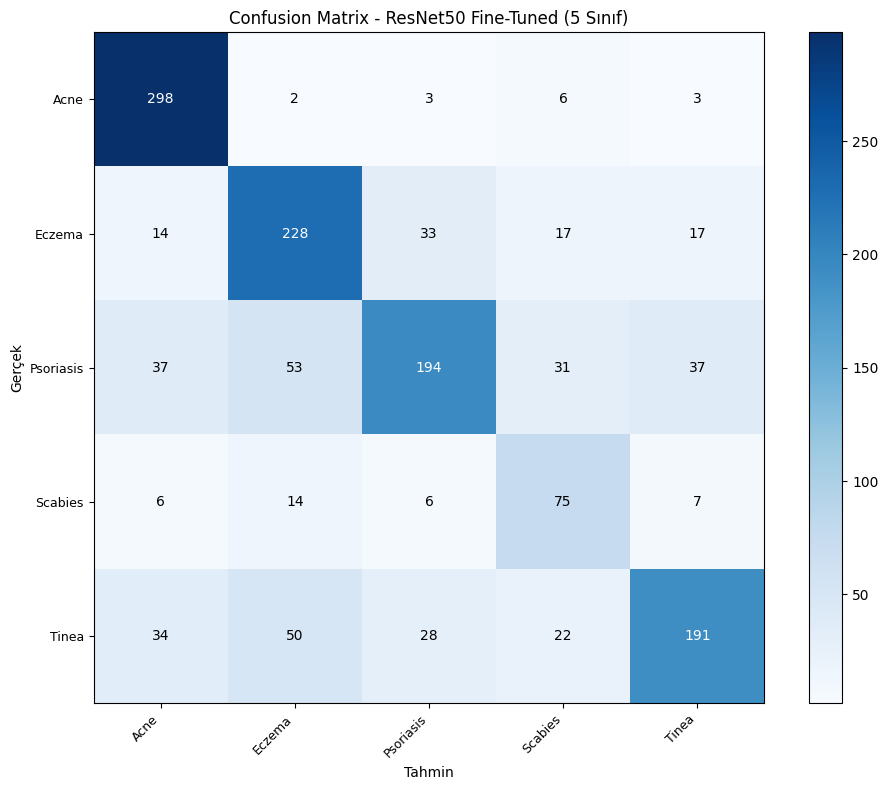

Kaydedildi -> confusion_matrix_resnet50.jpg


In [23]:
# ============================================================
# 19. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - ResNet50 Fine-Tuned (5 Sınıf)")
plt.colorbar()

short_names = [c.split(" ")[0] for c in class_names]
plt.xticks(range(NUM_CLASSES), short_names, rotation=45, ha="right", fontsize=9)
plt.yticks(range(NUM_CLASSES), short_names, fontsize=9)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=10)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.savefig(CM_SAVE_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Kaydedildi -> {CM_SAVE_PATH}")

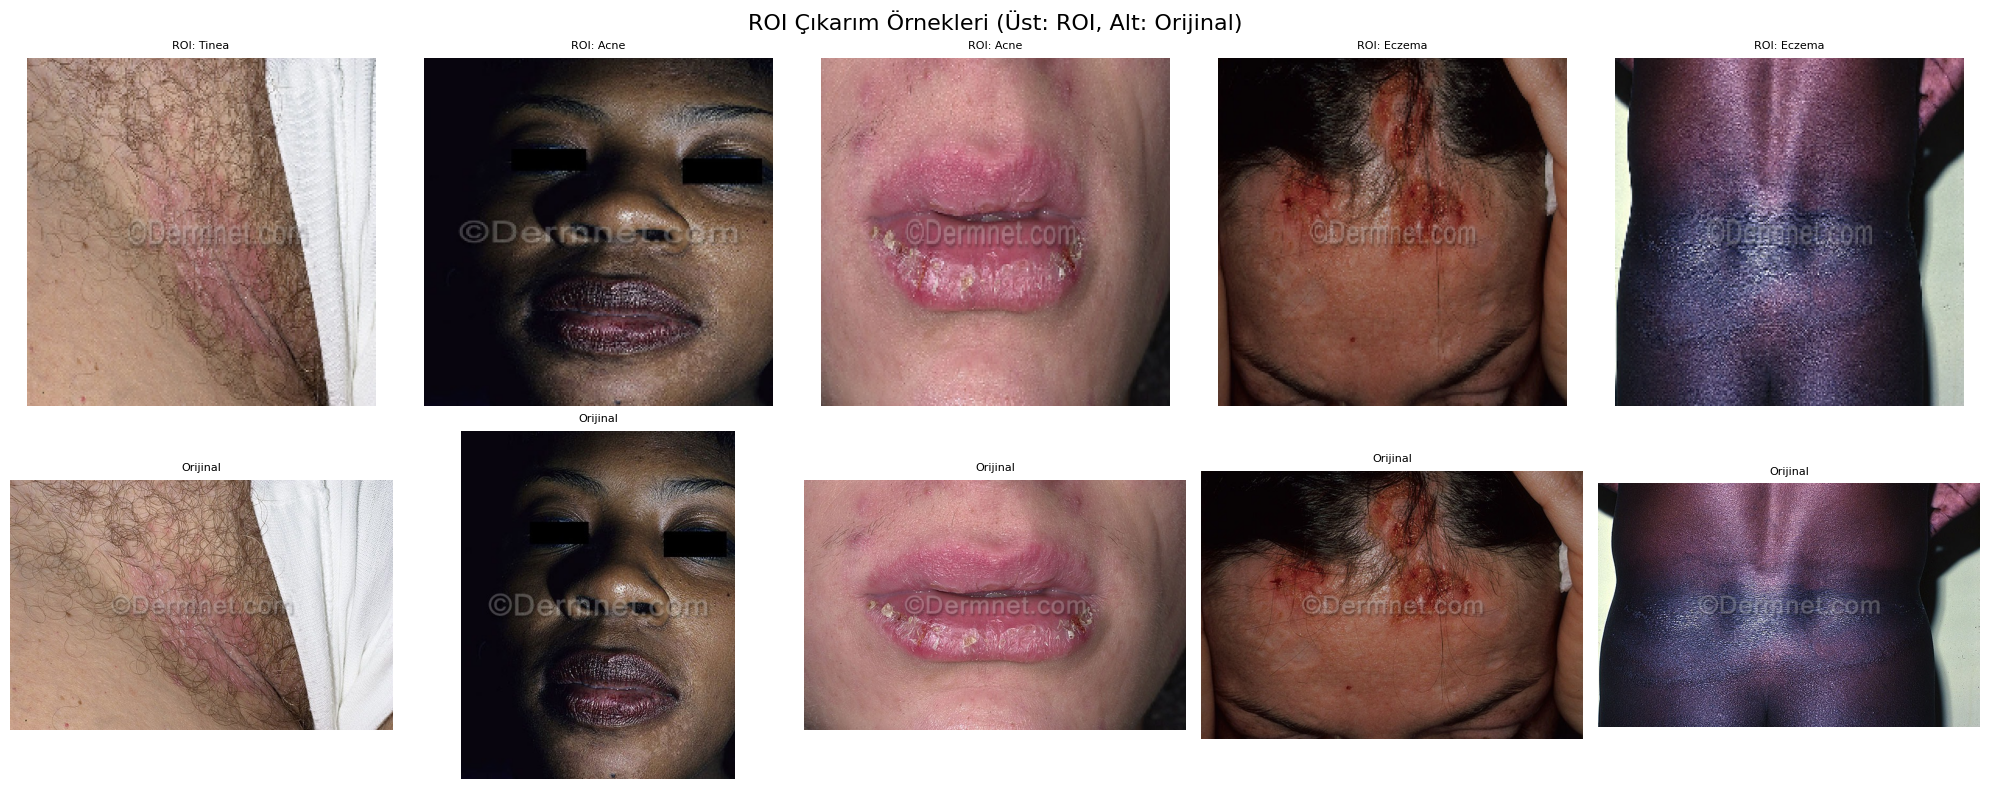

ROI örnek görseli kaydedildi!


In [24]:
# ============================================================
# 20. ROI ÖRNEK GÖRSELLEŞTİRME
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("ROI Çıkarım Örnekleri (Üst: ROI, Alt: Orijinal)", fontsize=16)

sample_indices = random.sample(range(len(test_dataset)), 5)

for i, idx in enumerate(sample_indices):
    img_path, label = test_dataset.samples[idx]

    roi = extract_roi(img_path, IMG_SIZE)
    if roi is not None:
        axes[0, i].imshow(roi)
    axes[0, i].set_title(f"ROI: {class_names[label]}", fontsize=8)
    axes[0, i].axis("off")

    orig = cv2.imread(img_path)
    if orig is not None:
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(orig)
    axes[1, i].set_title("Orijinal", fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("roi_examples_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()

print("ROI örnek görseli kaydedildi!")

In [25]:
# ============================================================
# 21. BİTTİ
# ============================================================
print("\nHer şey tamamlandı!")
print("Model: ResNet50")
print(f"Sınıf sayısı: {NUM_CLASSES}")
print(f"Sınıflar: {class_names}")
print(f"Final Accuracy: {test_acc:.4f}")
print(f"Final F1 Score: {test_f1:.4f}")

if device.type == "cuda":
    print(f"Max VRAM: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")

cache_path = Path(ROI_CACHE_DIR)
if cache_path.exists():
    cache_files = list(cache_path.glob("*.npy"))
    total_mb = sum(f.stat().st_size for f in cache_files) / (1024 * 1024)
    print(f"ROI önbellek: {len(cache_files)} dosya, {total_mb:.1f} MB")


Her şey tamamlandı!
Model: ResNet50
Sınıf sayısı: 5
Sınıflar: ['Acne', 'Eczema', 'Psoriasis', 'Scabies', 'Tinea']
Final Accuracy: 0.7013
Final F1 Score: 0.6959
Max VRAM: 903 MB
ROI önbellek: 6617 dosya, 950.7 MB


Accuracy: 0.7013
Precision: 0.7097
Recall: 0.7013
F1 Score: 0.6959


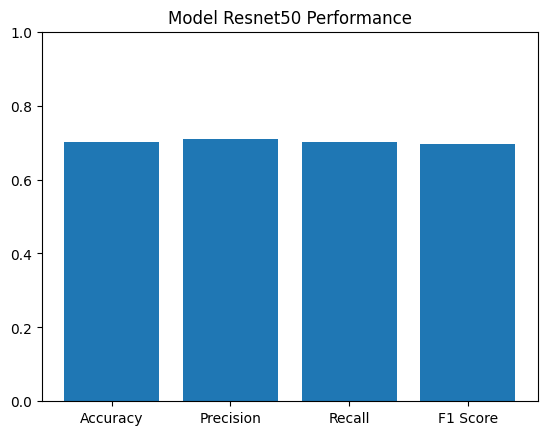

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Kaydettiğin dosyalar
y_true = np.load("test_labels.npy")
y_probs = np.load("probabilities_resnet50.npy")

# Tahmin
y_pred = np.argmax(y_probs, axis=1)

# 🔹 METRİKLER
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", round(acc, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

# 🔹 BAR GRAFİK
metrics = [acc, precision, recall, f1]
names = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure()
plt.bar(names, metrics)
plt.title("Model Resnet50 Performance")
plt.ylim(0, 1)  # 0-1 arası sabit olsun daha temiz görünür
plt.show()